# 01 — ShuttleSet Exploratory Data Analysis

This notebook performs EDA on the ShuttleSet dataset:
1. **Pipeline coverage** — How many of the 44 matches were successfully processed?
2. **Failed downloads** — Which videos failed (broken YouTube links)?
3. **Shot type distribution** — Class balance across all processed matches
4. **Per-match statistics** — Strokes per match, rallies, sets
5. **Rally length analysis** — Distribution of rally lengths
6. **Shot transition matrix** — Which shot types follow which?
7. **Court position heatmaps** — Hit/landing coordinate distributions
8. **Annotation completeness** — Missing values analysis
9. **Tournament & player breakdown** — Coverage by event and player

In [3]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


In [4]:
import sys
sys.path.insert(0, '..')

import json
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

from src.config import (
    SS_CSV_ROOT, SS_MATCH_CSV, SS_FRAMES, SS_OUTPUTS,
    SS_SHOT_TYPES, SS_PREPROCESS_ROOT
)

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

# Shot type translation for readability (used throughout)
SHOT_TYPE_EN = {
    '發短球': 'Short Serve',
    '發長球': 'Long Serve',
    '推撲球': 'Push/Rush',
    '殺球': 'Smash',
    '過渡球': 'Transition',
    '防守回挑': 'Defensive Lift',
    '切球': 'Slice/Cut',
    '接殺防守': 'Smash Defense',
    '長球': 'Clear',
    '平球': 'Drive',
    '擋小球': 'Block',
    '挑球': 'Lift',
    '放小球': 'Drop (Net)',
    '勾球': 'Cross-Net',
    '網前球': 'Net Shot',
    '點扣': 'Tap Smash',
    '推球': 'Push',
    '未知': 'Unknown',
}

## 1. Pipeline Coverage — Which matches were processed?

In [5]:
# Load match.csv — the master list of all matches
match_df = pd.read_csv(SS_MATCH_CSV)
print(f"Total matches in match.csv: {len(match_df)}")
print(f"Columns: {list(match_df.columns)}")
match_df.head()

Total matches in match.csv: 44
Columns: ['id', 'video', 'tournament', 'round', 'year', 'month', 'day', 'set', 'duration', 'winner', 'loser', 'downcourt', 'url']


,id,video,tournament,round,year,month,day,set,duration,winner,loser,downcourt,url
0,1,Kento_MOMOTA_CHOU_Tien_Chen_Fuzhou_Open_2019_F...,Fuzhou Open 2019,Finals,2019,11,10,3,83,Kento MOMOTA,CHOU Tien Chen,0,https://www.youtube.com/watch?v=O669aZhH0LI
1,2,CHEN_Long_CHOU_Tien_Chen_World_Tour_Finals_Gro...,World Tour Finals,Group-Stage,2019,12,13,2,52,CHEN Long,CHOU Tien Chen,1,https://www.youtube.com/watch?v=-aOI9_JxoWc
2,3,Kento_MOMOTA_CHOU_Tien_Chen_KOREA_OPEN_2019_Final,KOREA OPEN 2019,Finals,2019,9,29,2,53,Kento MOMOTA,CHOU Tien Chen,1,https://www.youtube.com/watch?v=eugfCRwSBJo
3,4,CHEN_Long_CHOU_Tien_Chen_Denmark_Open_2019_Qua...,Denmark Open 2019,Quarter-finals,2019,10,17,2,54,CHEN Long,CHOU Tien Chen,0,https://www.youtube.com/watch?v=y6QbtrTV-K0
4,5,Kento_MOMOTA_CHOU_Tien_Chen_Fuzhou_Open_2018_F...,Fuzhou Open 2018,Finals,2018,11,11,3,67,Kento MOMOTA,CHOU Tien Chen,0,https://www.youtube.com/watch?v=xhUi2KpmVkI


In [6]:
# Check which matches have pipeline outputs (JSON files from streaming_pipeline.py)
output_jsons = {f.stem for f in SS_OUTPUTS.glob("*.json") if f.name != "pipeline_summary.json"}
all_match_ids = set(match_df["video"].str.strip())

processed = all_match_ids & output_jsons
not_processed = all_match_ids - output_jsons

# Tag each match
match_df["processed"] = match_df["video"].str.strip().isin(output_jsons)
match_df["has_url"] = match_df["url"].notna() & (match_df["url"].str.strip() != "")

print(f"Matches with pipeline output:  {len(processed)} / {len(all_match_ids)}")
print(f"Matches NOT processed:         {len(not_processed)}")
print(f"Matches without URL in CSV:    {(~match_df['has_url']).sum()}")

Matches with pipeline output:  25 / 44
Matches NOT processed:         19
Matches without URL in CSV:    1


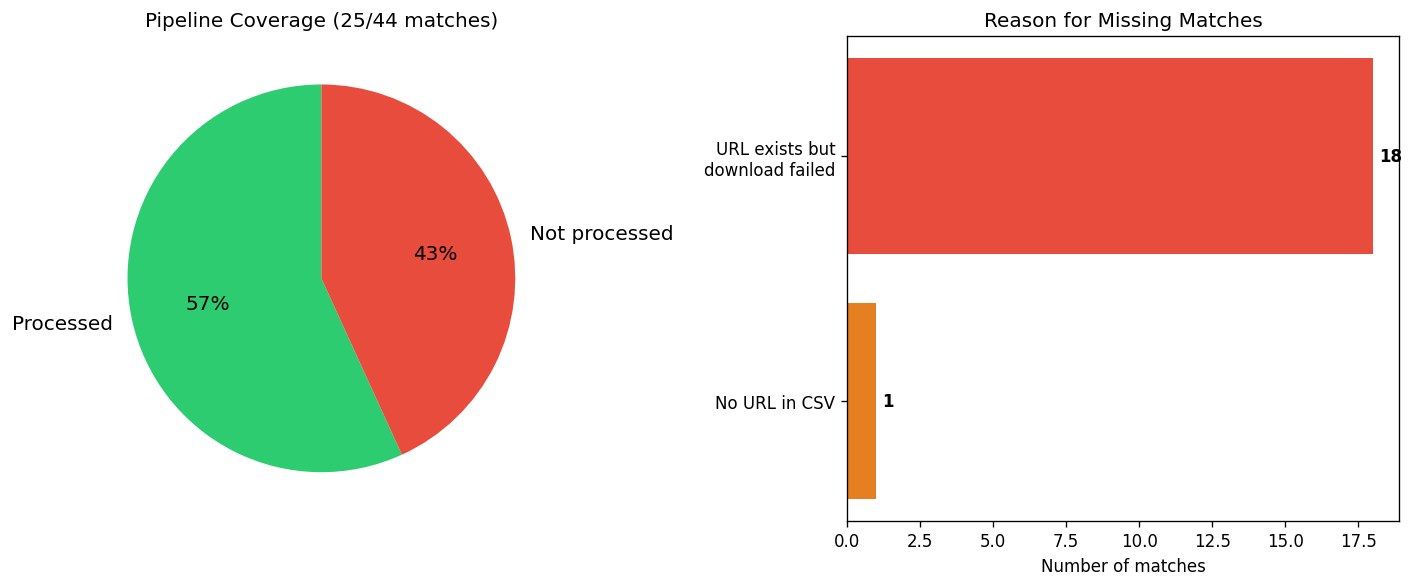

In [7]:
# Pipeline coverage pie chart + failure reasons
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie: processed vs not
labels = ["Processed", "Not processed"]
sizes = [len(processed), len(not_processed)]
colors = ["#2ecc71", "#e74c3c"]
axes[0].pie(sizes, labels=labels, colors=colors, autopct="%1.0f%%",
            startangle=90, textprops={"fontsize": 12})
axes[0].set_title(f"Pipeline Coverage ({len(processed)}/{len(all_match_ids)} matches)")

# Bar: reason for not processing
reasons = []
for _, row in match_df[~match_df["processed"]].iterrows():
    if not row["has_url"]:
        reasons.append("No URL in CSV")
    else:
        reasons.append("URL exists but\ndownload failed")

reason_counts = Counter(reasons)
r_labels = list(reason_counts.keys())
r_values = list(reason_counts.values())
bar_colors = ["#e67e22" if "No URL" in l else "#e74c3c" for l in r_labels]
axes[1].barh(r_labels, r_values, color=bar_colors)
axes[1].set_xlabel("Number of matches")
axes[1].set_title("Reason for Missing Matches")
for i, v in enumerate(r_values):
    axes[1].text(v + 0.2, i, str(v), va="center", fontweight="bold")

plt.tight_layout()
plt.show()

In [8]:
# List the unprocessed matches with their URLs
print("=== Unprocessed Matches ===")
print("(These likely have broken/removed YouTube links or missing URLs)\n")
for _, row in match_df[~match_df["processed"]].iterrows():
    url = row["url"] if row["has_url"] else "(no URL)"
    status = "NO URL" if not row["has_url"] else "BROKEN LINK?"
    print(f"  [{status}] {row['video']}")
    print(f"    URL: {url}")
    print(f"    Tournament: {row['tournament']}, {row['round']}")
    print()

=== Unprocessed Matches ===
(These likely have broken/removed YouTube links or missing URLs)

  [NO URL] NG_Ka_Long_Angus_SHI_Yu_Qi_Thailand_Masters_2020_SemiFinals
    URL: (no URL)
    Tournament: Thailand Masters 2020, Semi-finals

  [BROKEN LINK?] Viktor_Axelsen_Anthony_Sinisuka_Ginting_YONEX_Thailand_Open_2021_SemiFinals
    URL: https://www.youtube.com/watch?v=HTBf9wFL0mk
    Tournament: YONEX THAILAND OPEN 2021, Semi-finals

  [BROKEN LINK?] Viktor_Axelsen_Ng_Ka_Long_Angus_YONEX_Thailand_Open_2021_Finals
    URL: https://www.youtube.com/watch?v=IuXmsimDOW8
    Tournament: YONEX THAILAND OPEN 2021, Finals

  [BROKEN LINK?] An_Se_Young_Pornpawee_Chochuwong_TOYOTA_THAILAND_OPEN_2021_QuarterFinals
    URL: https://www.youtube.com/watch?v=TXT-qlniM90
    Tournament: TOYOTA THAILAND OPEN 2021, Quarter-finals

  [BROKEN LINK?] Anders_Antonsen_Sameer_Verma_TOYOTA_THAILAND_OPEN_2021_QuarterFinals
    URL: https://www.youtube.com/watch?v=YP8YlZkrQq8
    Tournament: TOYOTA THAILAND OPEN 20

## 2. Load All Processed Stroke Records

In [9]:
# Load all output JSONs into a single DataFrame
all_records = []
for json_file in sorted(SS_OUTPUTS.glob("*.json")):
    if json_file.name == "pipeline_summary.json":
        continue
    with open(json_file) as f:
        records = json.load(f)
        all_records.extend(records)

strokes_df = pd.DataFrame(all_records)
print(f"Total stroke records: {len(strokes_df)}")
print(f"Columns: {list(strokes_df.columns)}")
print(f"\nBasic stats:")
print(f"  Unique matches: {strokes_df['match_id'].nunique()}")
print(f"  Unique shot types: {strokes_df['type'].nunique()}")
print(f"  Players: {strokes_df['player'].unique()}")
strokes_df.head()

Total stroke records: 21191
Columns: ['match_id', 'set_file', 'rally', 'ball_round', 'frame_num', 'type', 'player', 'frame_prev', 'frame_curr', 'frame_next', 'hit_area', 'hit_x', 'hit_y', 'landing_area', 'landing_x', 'landing_y', 'player_location_x', 'player_location_y', 'opponent_location_x', 'opponent_location_y', 'backhand', 'hit_height']

Basic stats:
  Unique matches: 25
  Unique shot types: 19
  Players: ['B' 'A']


,match_id,set_file,rally,ball_round,frame_num,type,player,frame_prev,frame_curr,frame_next,...,hit_y,landing_area,landing_x,landing_y,player_location_x,player_location_y,opponent_location_x,opponent_location_y,backhand,hit_height
0,An_Se_Young_Ratchanok_Intanon_YONEX_Thailand_O...,set1.csv,1,1,12771,發長球,B,/Users/yuen@backbase.com/Documents/Baddiev2/Da...,/Users/yuen@backbase.com/Documents/Baddiev2/Da...,/Users/yuen@backbase.com/Documents/Baddiev2/Da...,...,NaN,9.0,552.0,307.0,679.0,518.0,562.0,332.0,NaN,2.0
1,An_Se_Young_Ratchanok_Intanon_YONEX_Thailand_O...,set1.csv,1,2,12835,點扣,A,/Users/yuen@backbase.com/Documents/Baddiev2/Da...,/Users/yuen@backbase.com/Documents/Baddiev2/Da...,/Users/yuen@backbase.com/Documents/Baddiev2/Da...,...,307.0,6.0,487.0,530.0,576.0,307.0,652.0,529.0,NaN,1.0
2,An_Se_Young_Ratchanok_Intanon_YONEX_Thailand_O...,set1.csv,1,3,12852,平球,B,/Users/yuen@backbase.com/Documents/Baddiev2/Da...,/Users/yuen@backbase.com/Documents/Baddiev2/Da...,/Users/yuen@backbase.com/Documents/Baddiev2/Da...,...,530.0,8.0,761.0,381.0,641.0,557.0,590.0,341.0,1.0,2.0
3,An_Se_Young_Ratchanok_Intanon_YONEX_Thailand_O...,set1.csv,1,4,12884,放小球,A,/Users/yuen@backbase.com/Documents/Baddiev2/Da...,/Users/yuen@backbase.com/Documents/Baddiev2/Da...,/Users/yuen@backbase.com/Documents/Baddiev2/Da...,...,381.0,7.0,606.0,483.0,709.0,389.0,674.0,541.0,1.0,2.0
4,An_Se_Young_Ratchanok_Intanon_YONEX_Thailand_O...,set1.csv,1,5,12907,挑球,B,/Users/yuen@backbase.com/Documents/Baddiev2/Da...,/Users/yuen@backbase.com/Documents/Baddiev2/Da...,/Users/yuen@backbase.com/Documents/Baddiev2/Da...,...,483.0,3.0,508.0,309.0,668.0,496.0,652.0,368.0,1.0,2.0


## 3. Shot Type Distribution

In [10]:
# Count shot types
type_counts = strokes_df["type"].value_counts()
print(f"Unique shot types: {len(type_counts)}\n")

for shot, count in type_counts.items():
    en = SHOT_TYPE_EN.get(shot, shot)
    pct = count / len(strokes_df) * 100
    print(f"  {shot} ({en}): {count:>5} ({pct:>5.1f}%)")

Unique shot types: 19

  放小球 (Drop (Net)):  3823 ( 18.0%)
  挑球 (Lift):  3159 ( 14.9%)
  擋小球 (Block):  2145 ( 10.1%)
  推球 (Push):  1686 (  8.0%)
  長球 (Clear):  1609 (  7.6%)
  殺球 (Smash):  1405 (  6.6%)
  發短球 (Short Serve):  1328 (  6.3%)
  切球 (Slice/Cut):  1208 (  5.7%)
  點扣 (Tap Smash):  1013 (  4.8%)
  勾球 (Cross-Net):   842 (  4.0%)
  過度切球 (過度切球):   787 (  3.7%)
  未知球種 (未知球種):   615 (  2.9%)
  平球 (Drive):   423 (  2.0%)
  撲球 (撲球):   280 (  1.3%)
  後場抽平球 (後場抽平球):   253 (  1.2%)
  防守回抽 (防守回抽):   238 (  1.1%)
  防守回挑 (Defensive Lift):   174 (  0.8%)
  發長球 (Long Serve):   164 (  0.8%)
  小平球 (小平球):    39 (  0.2%)


/var/folders/0_/3pl6888s5j13pjsxp4wzz1s00000gp/T/ipykernel_74425/3958122646.py:18: UserWarning: Glyph 25918 (\N{CJK UNIFIED IDEOGRAPH-653E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/0_/3pl6888s5j13pjsxp4wzz1s00000gp/T/ipykernel_74425/3958122646.py:18: UserWarning: Glyph 23567 (\N{CJK UNIFIED IDEOGRAPH-5C0F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/0_/3pl6888s5j13pjsxp4wzz1s00000gp/T/ipykernel_74425/3958122646.py:18: UserWarning: Glyph 29699 (\N{CJK UNIFIED IDEOGRAPH-7403}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/0_/3pl6888s5j13pjsxp4wzz1s00000gp/T/ipykernel_74425/3958122646.py:18: UserWarning: Glyph 25361 (\N{CJK UNIFIED IDEOGRAPH-6311}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/0_/3pl6888s5j13pjsxp4wzz1s00000gp/T/ipykernel_74425/3958122646.py:18: UserWarning: Glyph 25803 (\N{CJK UNIFIED IDEOGRAPH-64CB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/0_/3pl6

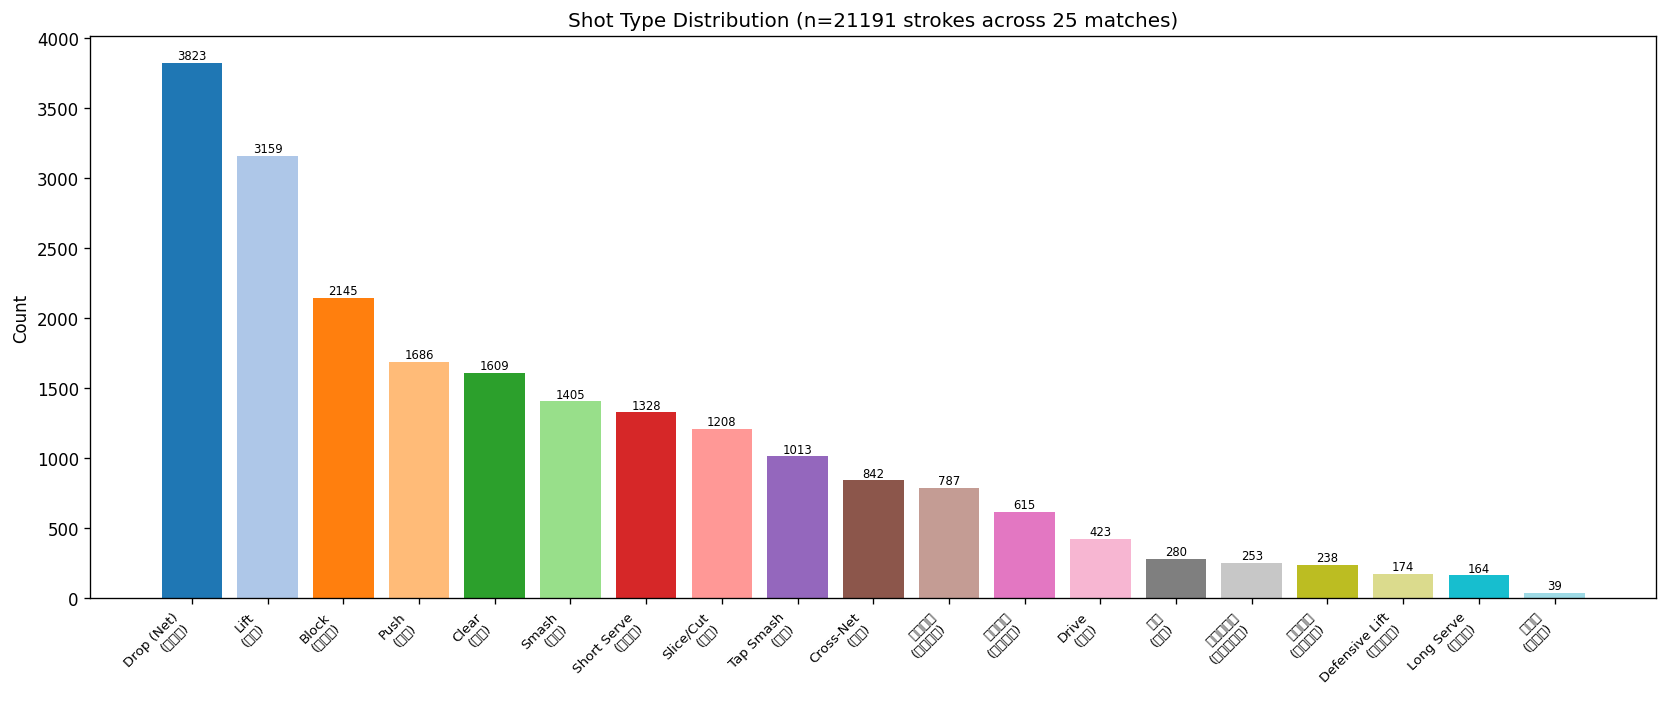


Class imbalance ratio (max/min): 98.0x
Most common:  放小球 (Drop (Net)) = 3823
Least common: 小平球 () = 39


In [11]:
# Shot type distribution bar chart
fig, ax = plt.subplots(figsize=(14, 6))

labels_en = [f"{SHOT_TYPE_EN.get(s, s)}\n({s})" for s in type_counts.index]
colors = plt.cm.tab20(np.linspace(0, 1, len(type_counts)))

bars = ax.bar(range(len(type_counts)), type_counts.values, color=colors)
ax.set_xticks(range(len(type_counts)))
ax.set_xticklabels(labels_en, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Count")
ax.set_title(f"Shot Type Distribution (n={len(strokes_df)} strokes across {len(processed)} matches)")

# Add count labels on bars
for bar, count in zip(bars, type_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(count), ha="center", va="bottom", fontsize=7)

plt.tight_layout()
plt.show()

# Class imbalance ratio
print(f"\nClass imbalance ratio (max/min): {type_counts.max() / type_counts.min():.1f}x")
print(f"Most common:  {type_counts.index[0]} ({SHOT_TYPE_EN.get(type_counts.index[0], '')}) = {type_counts.iloc[0]}")
print(f"Least common: {type_counts.index[-1]} ({SHOT_TYPE_EN.get(type_counts.index[-1], '')}) = {type_counts.iloc[-1]}")

## 4. Per-Match Statistics

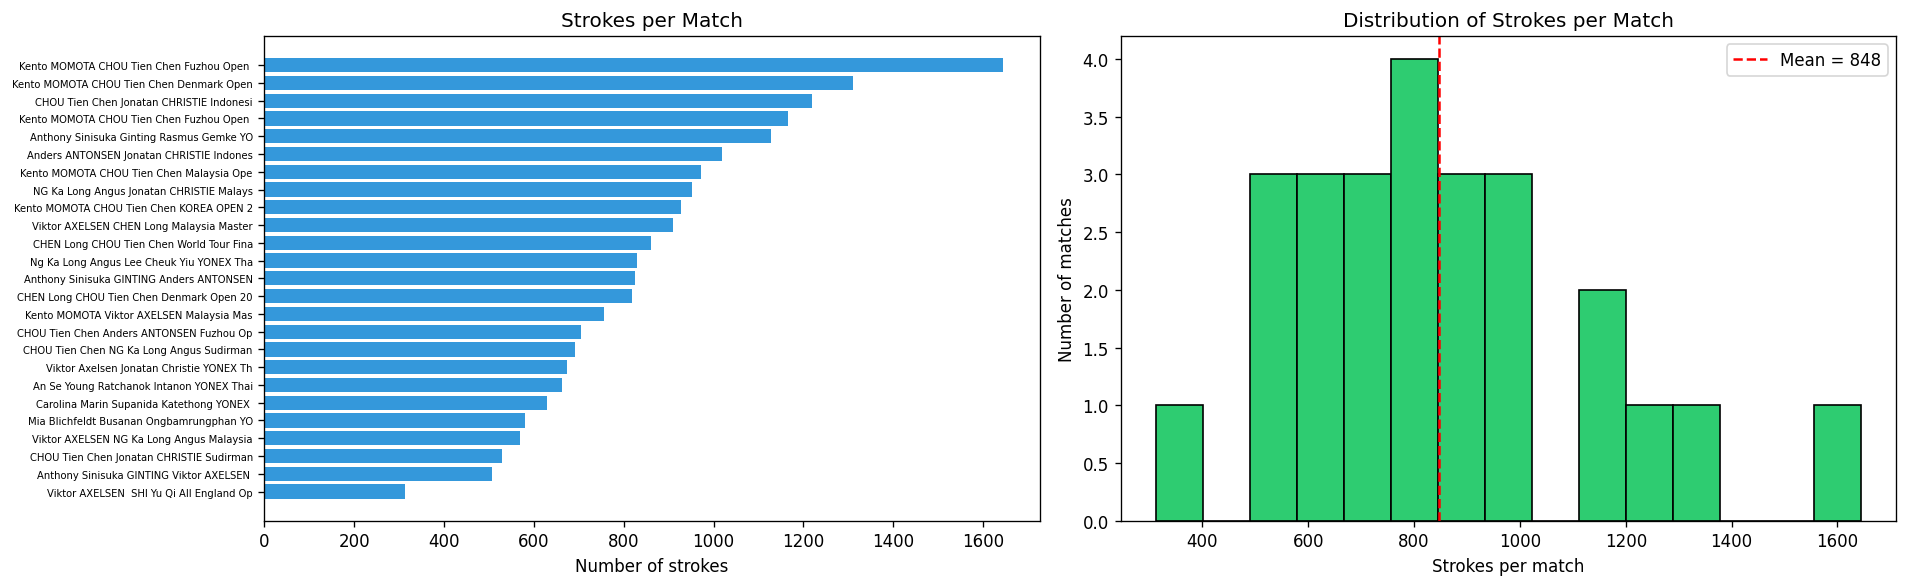

Strokes per match — min: 312, max: 1644, mean: 848, median: 824


In [12]:
# Strokes per match
match_stroke_counts = strokes_df.groupby("match_id").size().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar: strokes per match
axes[0].barh(range(len(match_stroke_counts)), match_stroke_counts.values, color="#3498db")
axes[0].set_yticks(range(len(match_stroke_counts)))
short_names = [m.replace("_", " ")[:40] for m in match_stroke_counts.index]
axes[0].set_yticklabels(short_names, fontsize=6)
axes[0].set_xlabel("Number of strokes")
axes[0].set_title("Strokes per Match")
axes[0].invert_yaxis()

# Histogram: distribution of strokes per match
axes[1].hist(match_stroke_counts.values, bins=15, color="#2ecc71", edgecolor="black")
axes[1].set_xlabel("Strokes per match")
axes[1].set_ylabel("Number of matches")
axes[1].set_title("Distribution of Strokes per Match")
axes[1].axvline(match_stroke_counts.mean(), color="red", linestyle="--",
                label=f"Mean = {match_stroke_counts.mean():.0f}")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Strokes per match — min: {match_stroke_counts.min()}, max: {match_stroke_counts.max()}, "
      f"mean: {match_stroke_counts.mean():.0f}, median: {match_stroke_counts.median():.0f}")

## 5. Rally Length Analysis

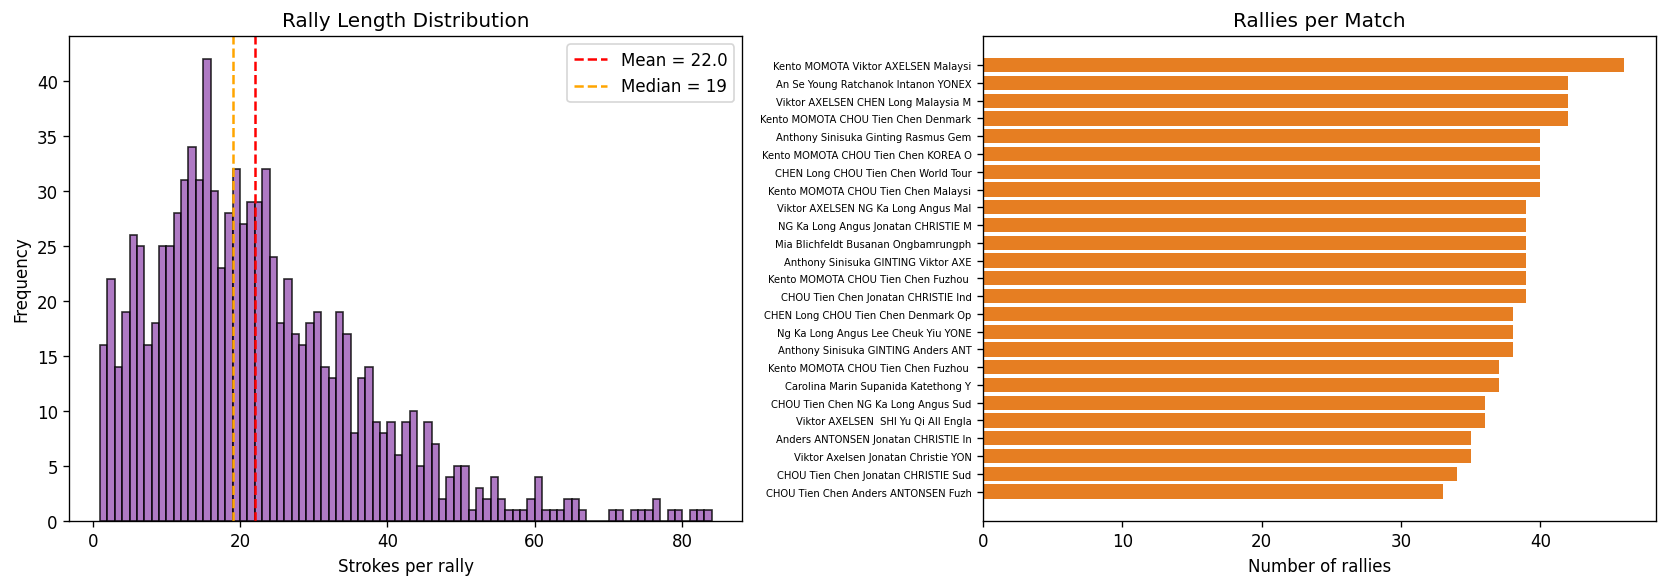

Total rallies: 963
Rally length — min: 1, max: 83, mean: 22.0


In [13]:
# Rally length = number of strokes (ball_round) per rally
rally_lengths = strokes_df.groupby(["match_id", "rally"]).size().reset_index(name="rally_len")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of rally lengths
axes[0].hist(rally_lengths["rally_len"], bins=range(1, rally_lengths["rally_len"].max() + 2),
             color="#9b59b6", edgecolor="black", alpha=0.8)
axes[0].set_xlabel("Strokes per rally")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Rally Length Distribution")
axes[0].axvline(rally_lengths["rally_len"].mean(), color="red", linestyle="--",
                label=f"Mean = {rally_lengths['rally_len'].mean():.1f}")
axes[0].axvline(rally_lengths["rally_len"].median(), color="orange", linestyle="--",
                label=f"Median = {rally_lengths['rally_len'].median():.0f}")
axes[0].legend()

# Rallies per match
rallies_per_match = rally_lengths.groupby("match_id").size().sort_values(ascending=False)
axes[1].barh(range(len(rallies_per_match)), rallies_per_match.values, color="#e67e22")
axes[1].set_yticks(range(len(rallies_per_match)))
axes[1].set_yticklabels([m.replace("_", " ")[:35] for m in rallies_per_match.index], fontsize=6)
axes[1].set_xlabel("Number of rallies")
axes[1].set_title("Rallies per Match")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print(f"Total rallies: {len(rally_lengths)}")
print(f"Rally length — min: {rally_lengths['rally_len'].min()}, max: {rally_lengths['rally_len'].max()}, "
      f"mean: {rally_lengths['rally_len'].mean():.1f}")

## 6. Shot Transition Matrix (Confusion-style)

Shows which shot types tend to follow which — a proxy for tactical sequences.

/Users/yuen@backbase.com/Documents/Baddiev2/.venv/lib/python3.10/site-packages/seaborn/utils.py:61: UserWarning: Glyph 36942 (\N{CJK UNIFIED IDEOGRAPH-904E}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Users/yuen@backbase.com/Documents/Baddiev2/.venv/lib/python3.10/site-packages/seaborn/utils.py:61: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Users/yuen@backbase.com/Documents/Baddiev2/.venv/lib/python3.10/site-packages/seaborn/utils.py:61: UserWarning: Glyph 20999 (\N{CJK UNIFIED IDEOGRAPH-5207}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Users/yuen@backbase.com/Documents/Baddiev2/.venv/lib/python3.10/site-packages/seaborn/utils.py:61: UserWarning: Glyph 29699 (\N{CJK UNIFIED IDEOGRAPH-7403}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Users/yuen@backbase.com/Documents/Baddiev2/.venv/lib/python3.10/site-packages/seaborn/utils.py:61: UserWarning: Glyph 26410 (\N{CJK UNIFIED IDEOGRAPH-6

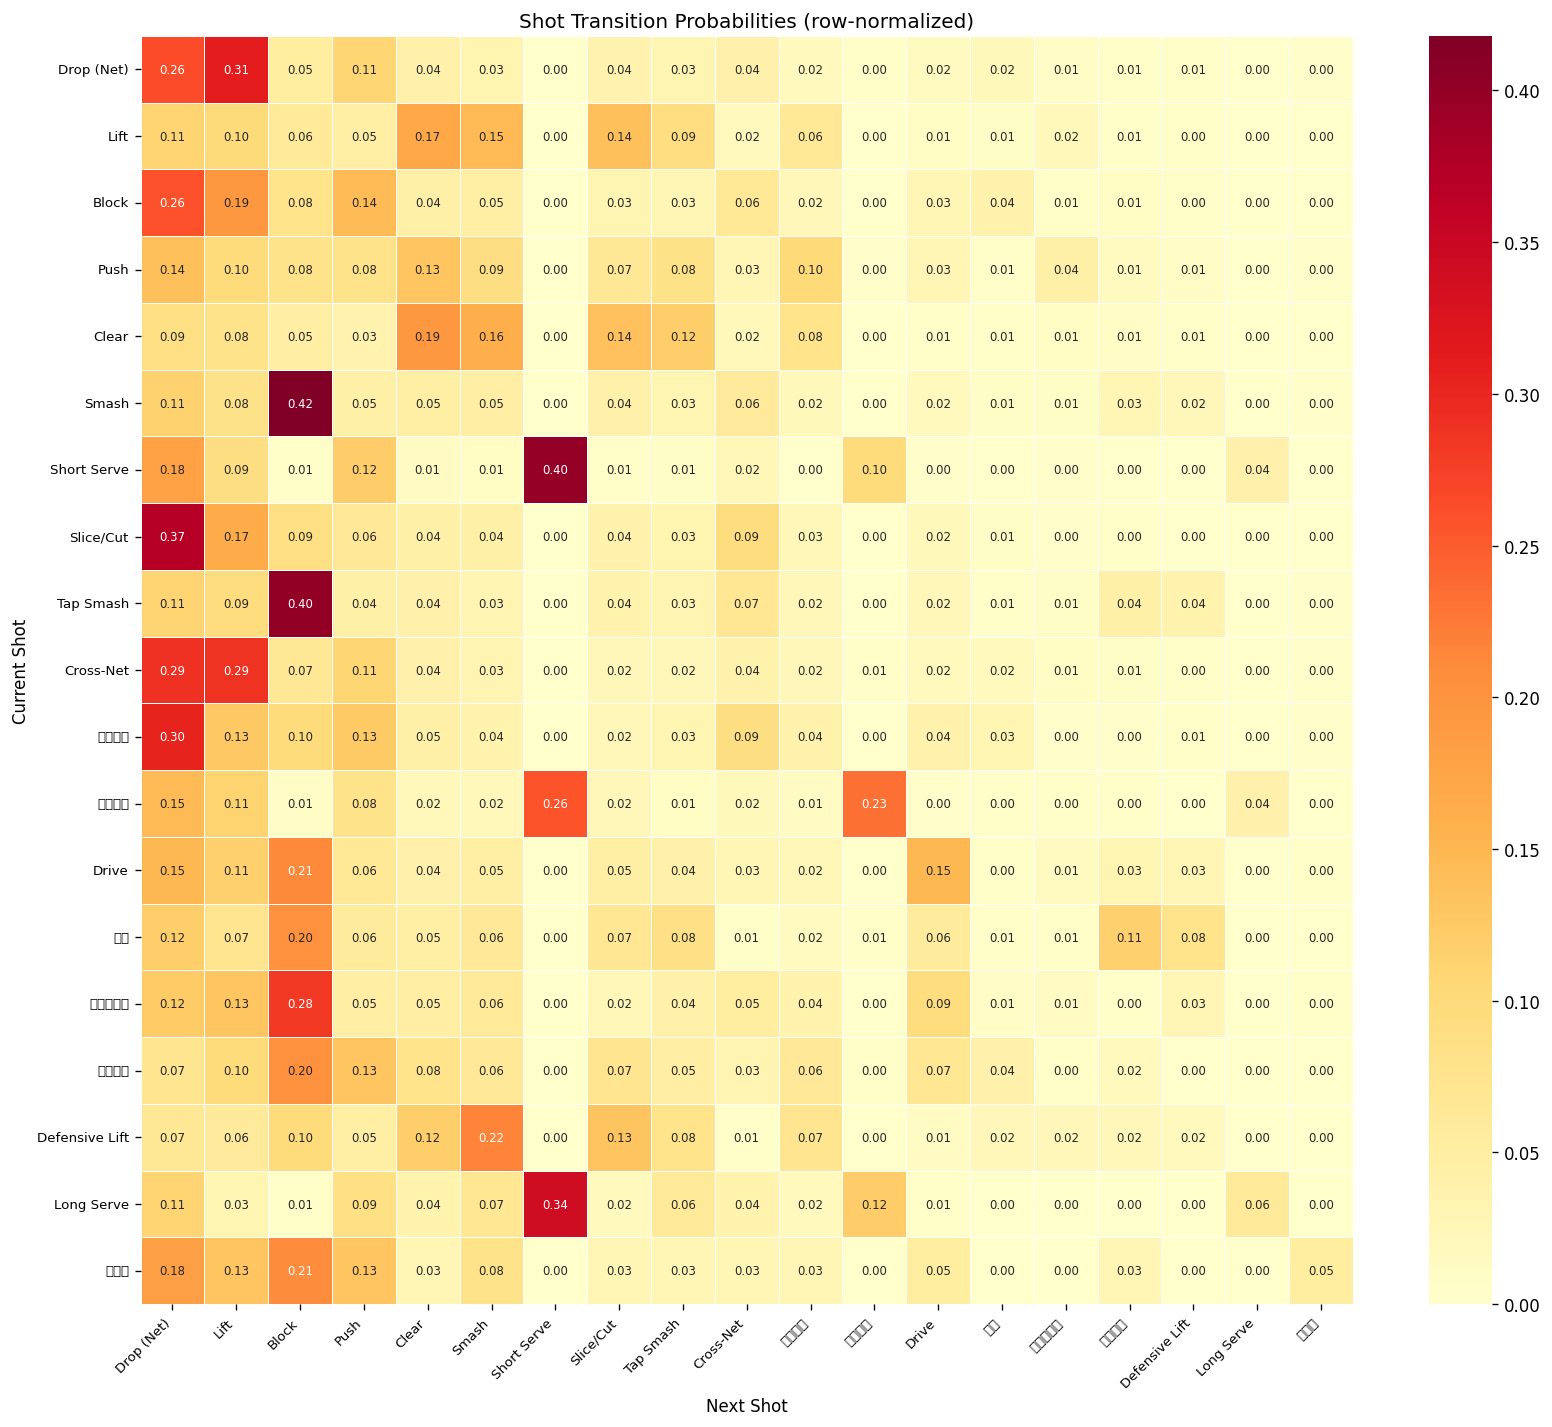

In [14]:
# Build shot-to-shot transition matrix within each rally
transitions = Counter()
for (match_id, rally), group in strokes_df.groupby(["match_id", "rally"]):
    shots = group.sort_values("ball_round")["type"].tolist()
    for i in range(len(shots) - 1):
        transitions[(shots[i], shots[i+1])] += 1

# Build matrix
all_types = type_counts.index.tolist()  # sorted by frequency
trans_matrix = pd.DataFrame(0, index=all_types, columns=all_types)
for (src, dst), count in transitions.items():
    if src in trans_matrix.index and dst in trans_matrix.columns:
        trans_matrix.loc[src, dst] = count

# Normalize rows to get transition probabilities
trans_prob = trans_matrix.div(trans_matrix.sum(axis=1), axis=0).fillna(0)

# Plot
fig, ax = plt.subplots(figsize=(14, 12))
en_labels = [SHOT_TYPE_EN.get(s, s) for s in all_types]

sns.heatmap(trans_prob, annot=True, fmt=".2f", cmap="YlOrRd",
            xticklabels=en_labels, yticklabels=en_labels,
            ax=ax, linewidths=0.5, annot_kws={"size": 7})
ax.set_xlabel("Next Shot")
ax.set_ylabel("Current Shot")
ax.set_title("Shot Transition Probabilities (row-normalized)")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

## 7. Court Position Analysis

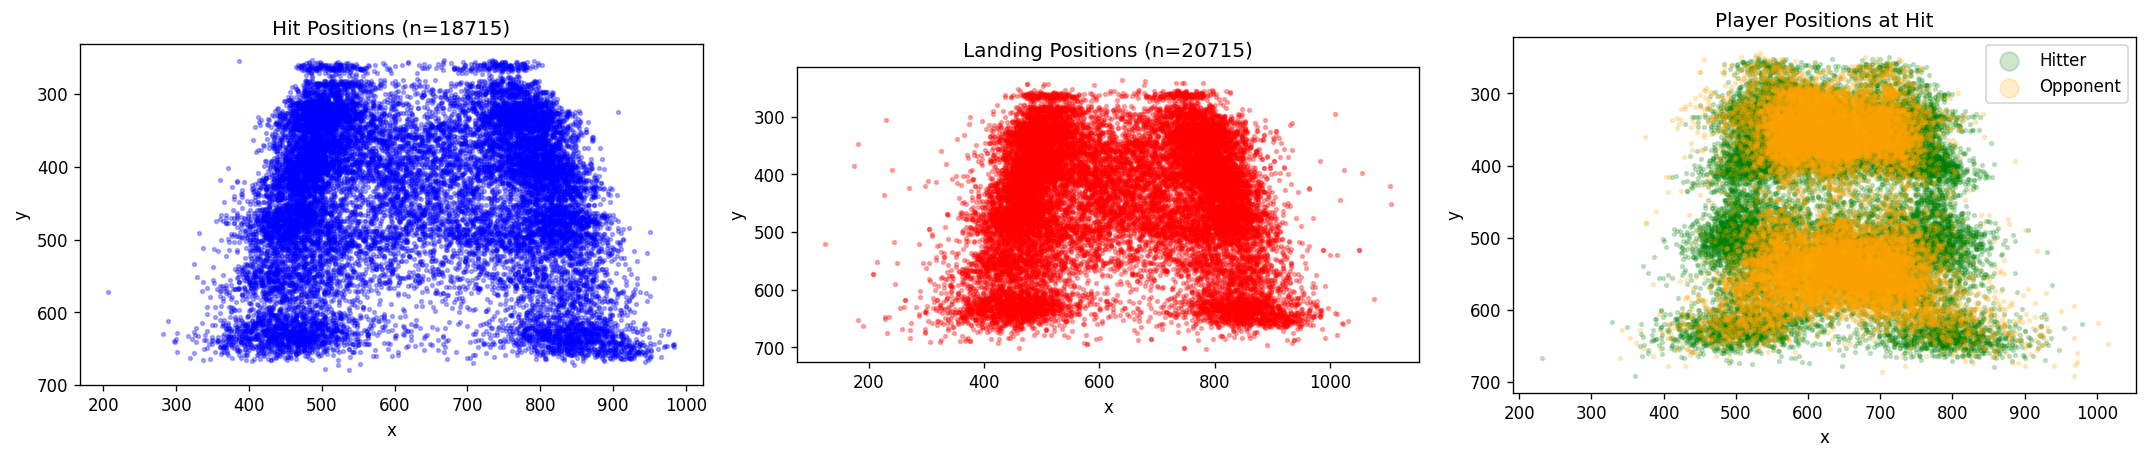

In [15]:
# Hit and landing position scatter plots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Hit positions
hit_mask = strokes_df["hit_x"].notna() & strokes_df["hit_y"].notna()
if hit_mask.sum() > 0:
    axes[0].scatter(strokes_df.loc[hit_mask, "hit_x"],
                    strokes_df.loc[hit_mask, "hit_y"],
                    alpha=0.3, s=5, c="blue")
    axes[0].set_title(f"Hit Positions (n={hit_mask.sum()})")
    axes[0].set_xlabel("x")
    axes[0].set_ylabel("y")
    axes[0].invert_yaxis()
    axes[0].set_aspect('equal')

# Landing positions
land_mask = strokes_df["landing_x"].notna() & strokes_df["landing_y"].notna()
if land_mask.sum() > 0:
    axes[1].scatter(strokes_df.loc[land_mask, "landing_x"],
                    strokes_df.loc[land_mask, "landing_y"],
                    alpha=0.3, s=5, c="red")
    axes[1].set_title(f"Landing Positions (n={land_mask.sum()})")
    axes[1].set_xlabel("x")
    axes[1].set_ylabel("y")
    axes[1].invert_yaxis()
    axes[1].set_aspect('equal')

# Player positions
ploc_mask = strokes_df["player_location_x"].notna() & strokes_df["player_location_y"].notna()
oloc_mask = strokes_df["opponent_location_x"].notna() & strokes_df["opponent_location_y"].notna()
if ploc_mask.sum() > 0:
    axes[2].scatter(strokes_df.loc[ploc_mask, "player_location_x"],
                    strokes_df.loc[ploc_mask, "player_location_y"],
                    alpha=0.2, s=5, c="green", label="Hitter")
if oloc_mask.sum() > 0:
    axes[2].scatter(strokes_df.loc[oloc_mask, "opponent_location_x"],
                    strokes_df.loc[oloc_mask, "opponent_location_y"],
                    alpha=0.2, s=5, c="orange", label="Opponent")
axes[2].set_title("Player Positions at Hit")
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")
axes[2].invert_yaxis()
axes[2].set_aspect('equal')
axes[2].legend(markerscale=5)

plt.tight_layout()
plt.show()

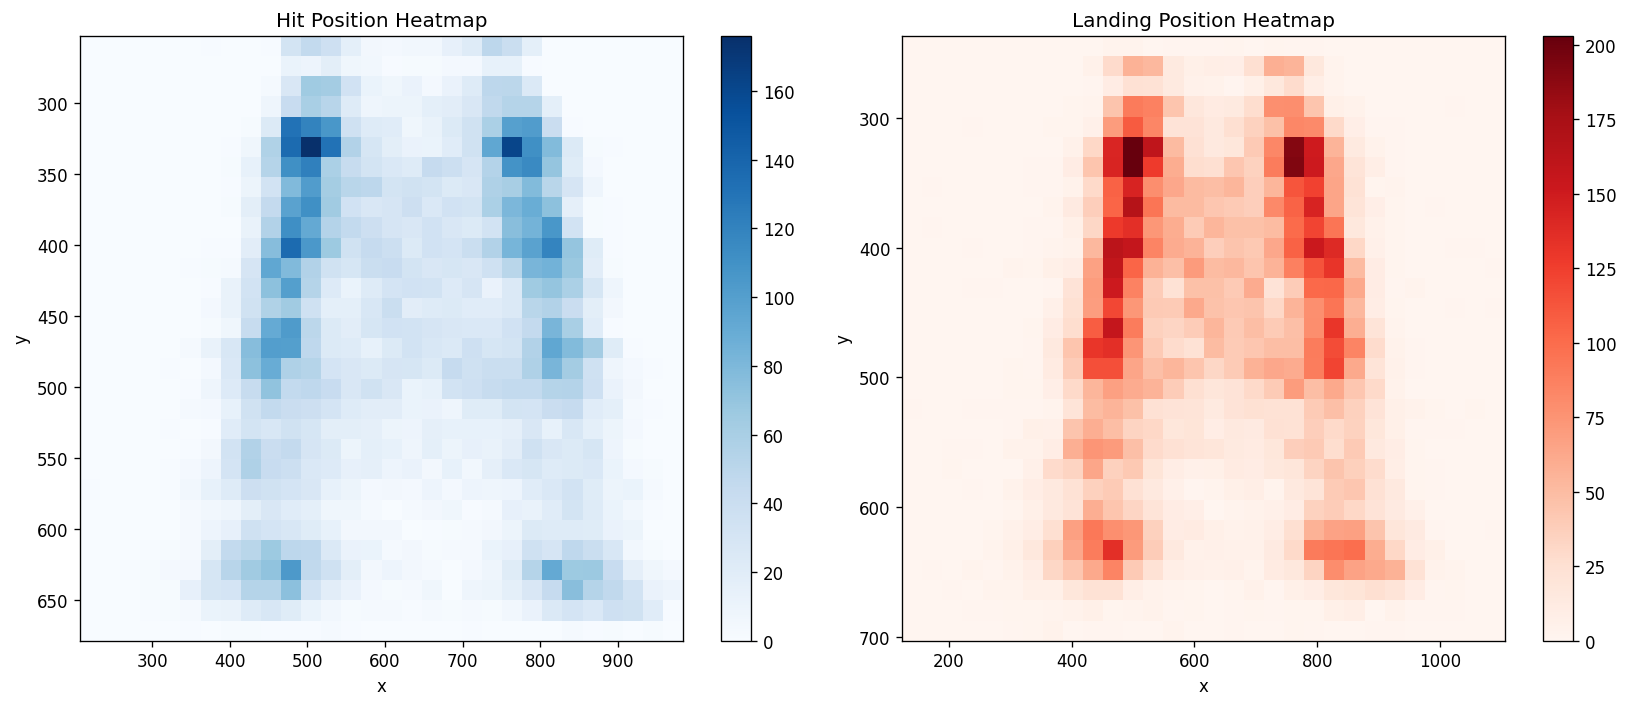

In [16]:
# Hit position heatmap (2D histogram)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

if hit_mask.sum() > 0:
    h = axes[0].hist2d(strokes_df.loc[hit_mask, "hit_x"].values,
                       strokes_df.loc[hit_mask, "hit_y"].values,
                       bins=30, cmap="Blues")
    plt.colorbar(h[3], ax=axes[0])
    axes[0].set_title("Hit Position Heatmap")
    axes[0].set_xlabel("x")
    axes[0].set_ylabel("y")
    axes[0].invert_yaxis()

if land_mask.sum() > 0:
    h = axes[1].hist2d(strokes_df.loc[land_mask, "landing_x"].values,
                       strokes_df.loc[land_mask, "landing_y"].values,
                       bins=30, cmap="Reds")
    plt.colorbar(h[3], ax=axes[1])
    axes[1].set_title("Landing Position Heatmap")
    axes[1].set_xlabel("x")
    axes[1].set_ylabel("y")
    axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 8. Annotation Completeness — Missing Values

Missing values per feature:
                     missing_count  missing_pct
backhand                     12929         61.0
hit_area                      2474         11.7
hit_x                         2476         11.7
hit_y                         2476         11.7
landing_area                   475          2.2
landing_x                      476          2.2
landing_y                      476          2.2
player_location_x              466          2.2
player_location_y              466          2.2
opponent_location_x            467          2.2
opponent_location_y            467          2.2
hit_height                      21          0.1


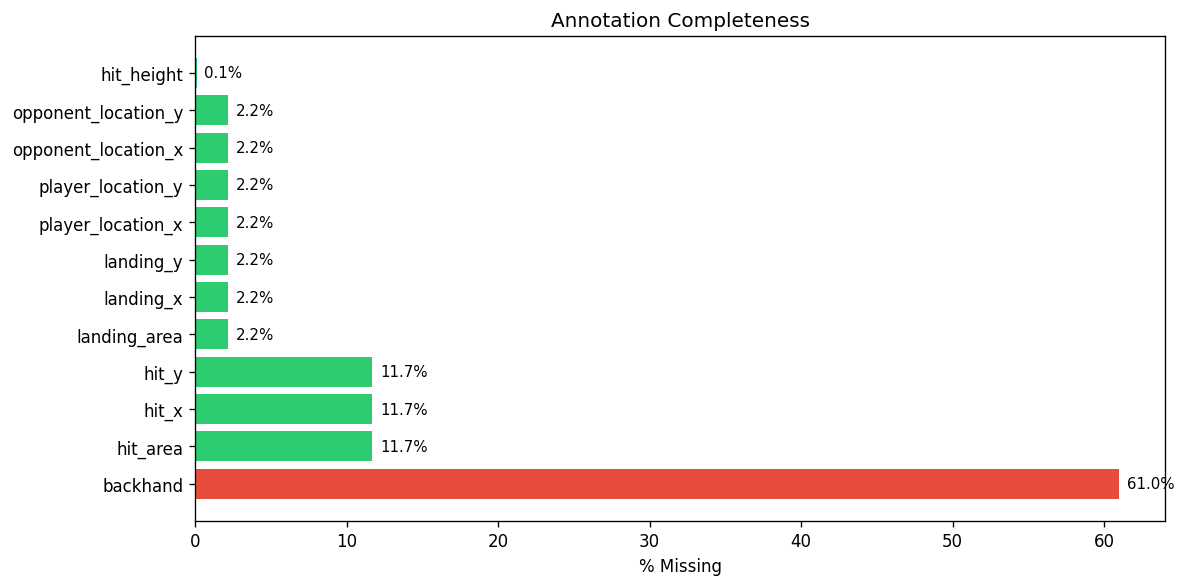

In [17]:
# Missing values analysis
feature_cols = ["hit_area", "hit_x", "hit_y", "landing_area", "landing_x", "landing_y",
                "player_location_x", "player_location_y",
                "opponent_location_x", "opponent_location_y",
                "backhand", "hit_height"]

missing_counts = strokes_df[feature_cols].isna().sum()
missing_pct = (missing_counts / len(strokes_df) * 100).round(1)

missing_df = pd.DataFrame({"missing_count": missing_counts, "missing_pct": missing_pct})
missing_df = missing_df.sort_values("missing_pct", ascending=False)

print("Missing values per feature:")
print(missing_df.to_string())

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#e74c3c" if p > 50 else "#e67e22" if p > 20 else "#2ecc71" for p in missing_df["missing_pct"]]
ax.barh(missing_df.index, missing_df["missing_pct"], color=colors)
ax.set_xlabel("% Missing")
ax.set_title("Annotation Completeness")
for i, (idx, row) in enumerate(missing_df.iterrows()):
    ax.text(row["missing_pct"] + 0.5, i, f"{row['missing_pct']}%", va="center", fontsize=9)
plt.tight_layout()
plt.show()

## 9. Tournament & Player Breakdown

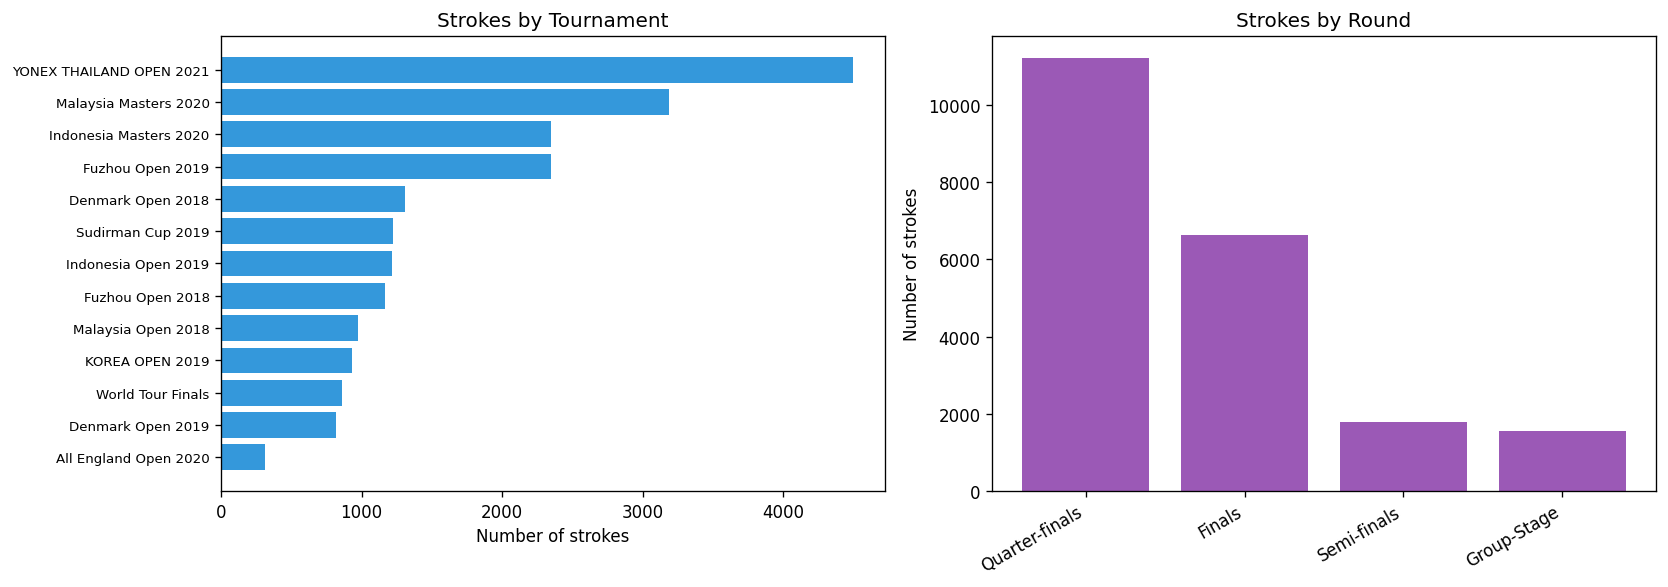

In [18]:
# Merge tournament info from match_df into strokes
match_info = match_df[["video", "tournament", "round", "year", "winner", "loser", "set"]].copy()
match_info = match_info.rename(columns={"video": "match_id"})
match_info["match_id"] = match_info["match_id"].str.strip()
strokes_merged = strokes_df.merge(match_info, on="match_id", how="left")

# Tournament distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

tourn_counts = strokes_merged["tournament"].value_counts()
axes[0].barh(range(len(tourn_counts)), tourn_counts.values, color="#3498db")
axes[0].set_yticks(range(len(tourn_counts)))
axes[0].set_yticklabels(tourn_counts.index, fontsize=8)
axes[0].set_xlabel("Number of strokes")
axes[0].set_title("Strokes by Tournament")
axes[0].invert_yaxis()

# Round distribution
round_counts = strokes_merged["round"].value_counts()
axes[1].bar(range(len(round_counts)), round_counts.values, color="#9b59b6")
axes[1].set_xticks(range(len(round_counts)))
axes[1].set_xticklabels(round_counts.index, rotation=30, ha="right")
axes[1].set_ylabel("Number of strokes")
axes[1].set_title("Strokes by Round")

plt.tight_layout()
plt.show()

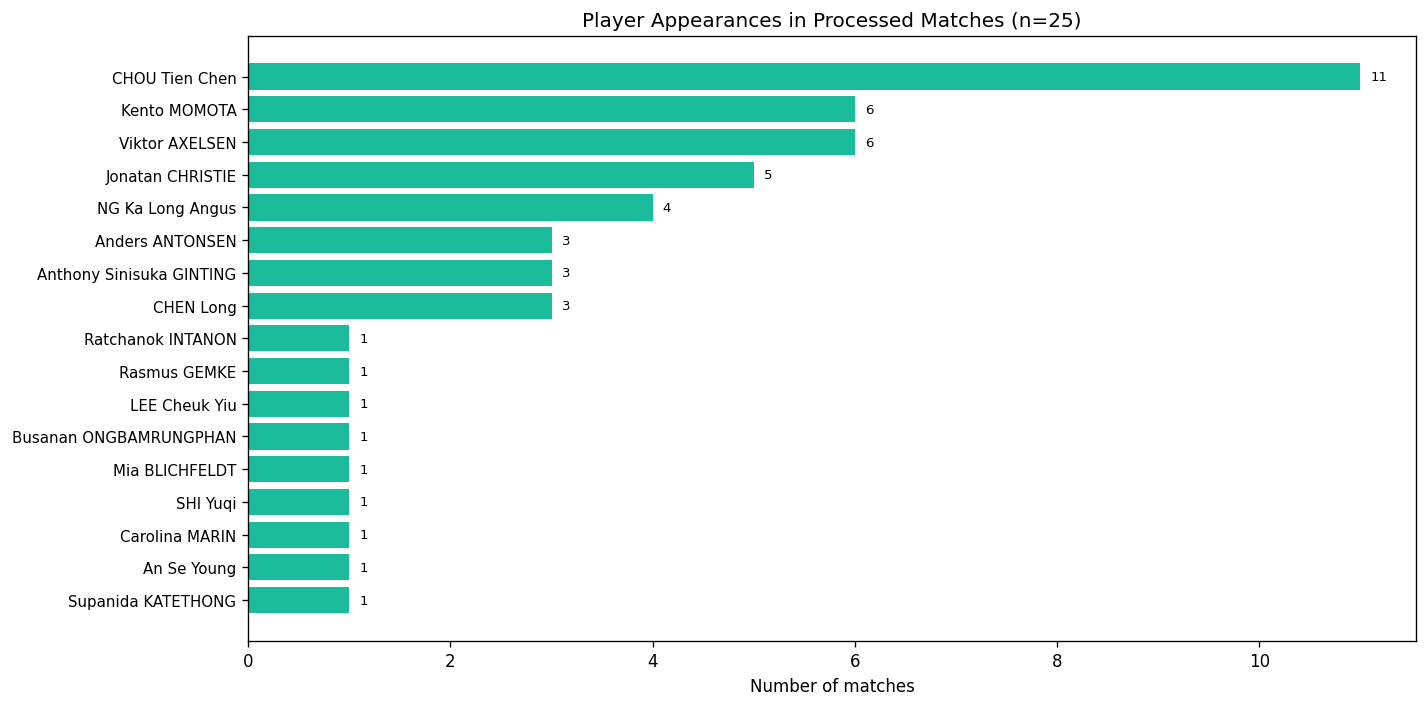

In [19]:
# Player appearance frequency (as winner or loser in processed matches)
processed_matches = match_df[match_df["processed"]]
all_players = pd.concat([processed_matches["winner"], processed_matches["loser"]])
player_counts = all_players.value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(range(len(player_counts)), player_counts.values, color="#1abc9c")
ax.set_yticks(range(len(player_counts)))
ax.set_yticklabels(player_counts.index, fontsize=9)
ax.set_xlabel("Number of matches")
ax.set_title(f"Player Appearances in Processed Matches (n={len(processed_matches)})")
ax.invert_yaxis()
for i, v in enumerate(player_counts.values):
    ax.text(v + 0.1, i, str(v), va="center", fontsize=8)
plt.tight_layout()
plt.show()

## 10. Shot Type Distribution per Match (Heatmap)

/Users/yuen@backbase.com/Documents/Baddiev2/.venv/lib/python3.10/site-packages/seaborn/utils.py:61: UserWarning: Glyph 23567 (\N{CJK UNIFIED IDEOGRAPH-5C0F}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Users/yuen@backbase.com/Documents/Baddiev2/.venv/lib/python3.10/site-packages/seaborn/utils.py:61: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Users/yuen@backbase.com/Documents/Baddiev2/.venv/lib/python3.10/site-packages/seaborn/utils.py:61: UserWarning: Glyph 29699 (\N{CJK UNIFIED IDEOGRAPH-7403}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Users/yuen@backbase.com/Documents/Baddiev2/.venv/lib/python3.10/site-packages/seaborn/utils.py:61: UserWarning: Glyph 24460 (\N{CJK UNIFIED IDEOGRAPH-5F8C}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Users/yuen@backbase.com/Documents/Baddiev2/.venv/lib/python3.10/site-packages/seaborn/utils.py:61: UserWarning: Glyph 22580 (\N{CJK UNIFIED IDEOGRAPH-5

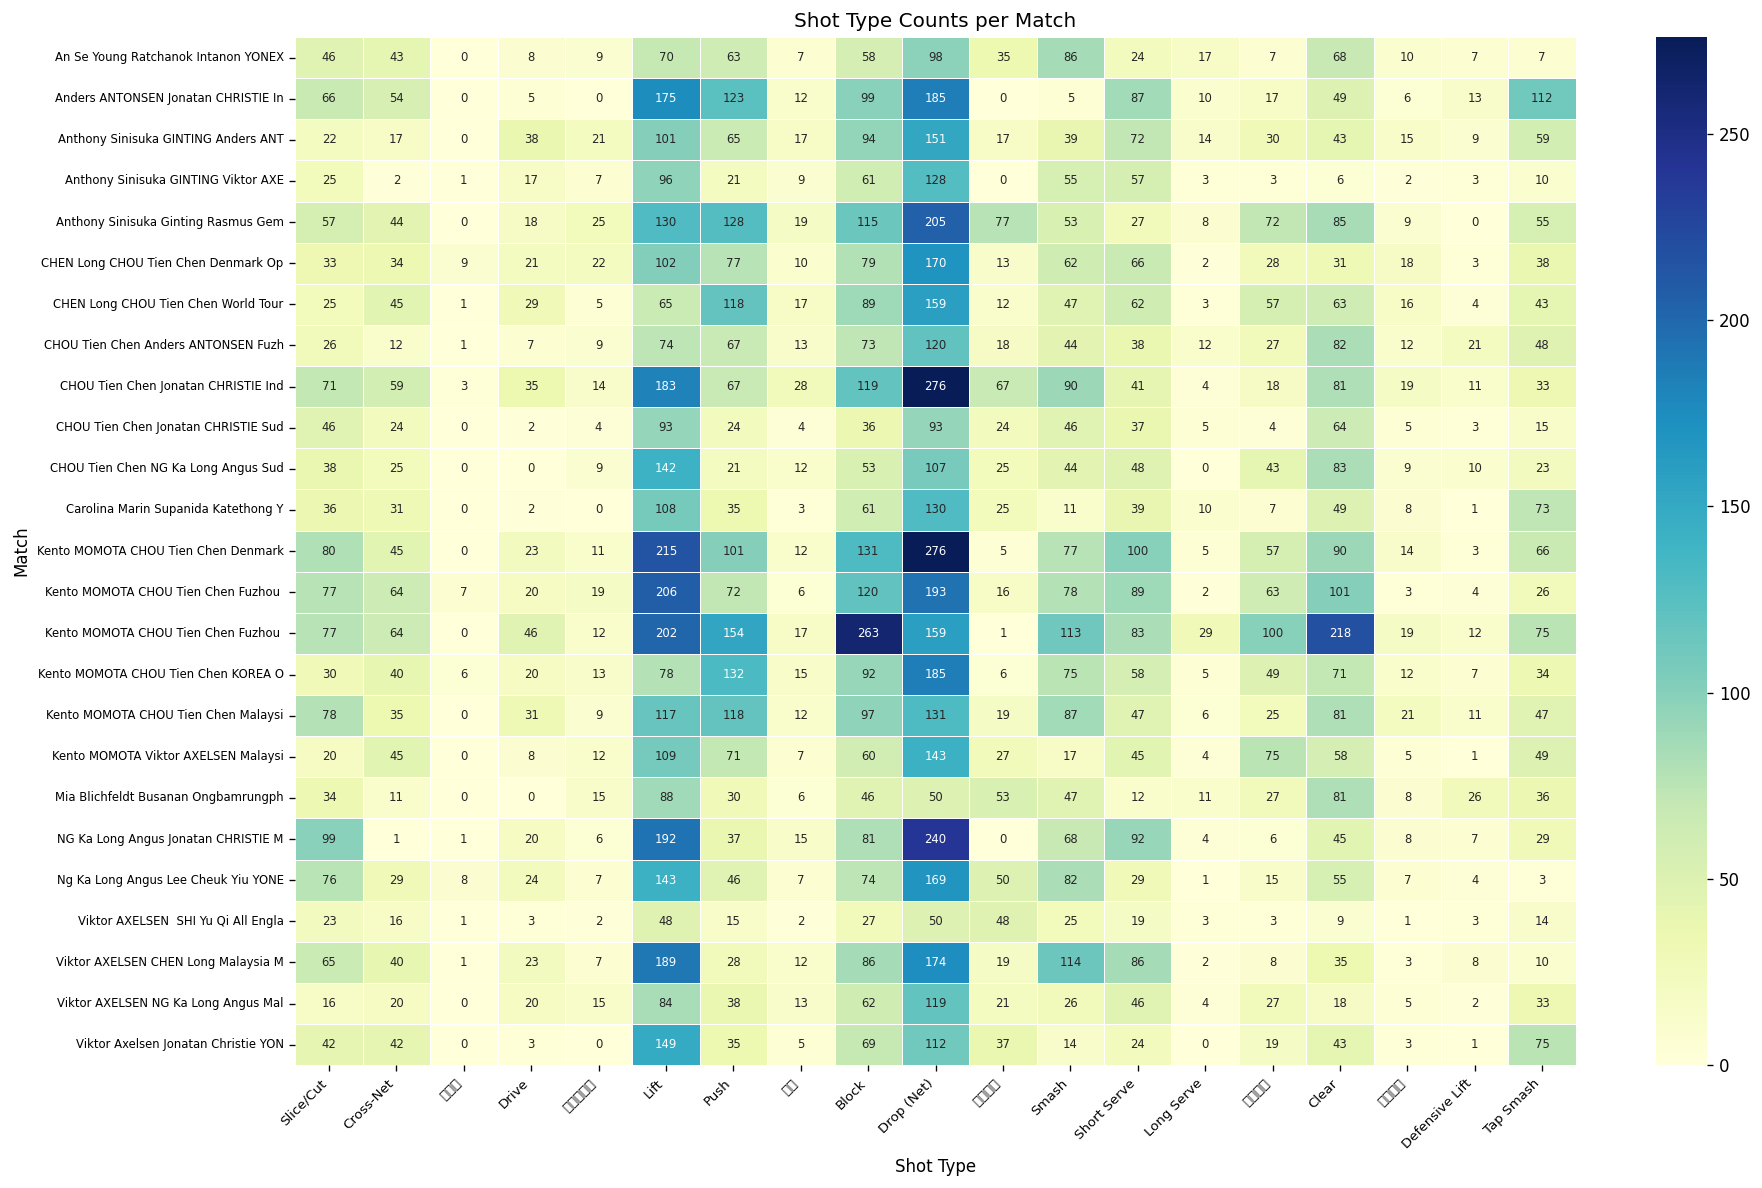

In [20]:
# Shot type per match heatmap
shot_per_match = strokes_df.groupby(["match_id", "type"]).size().unstack(fill_value=0)
# Rename columns to English
shot_per_match.columns = [SHOT_TYPE_EN.get(c, c) for c in shot_per_match.columns]
# Shorten match names for display
shot_per_match.index = [m.replace("_", " ")[:35] for m in shot_per_match.index]

fig, ax = plt.subplots(figsize=(16, 10))
sns.heatmap(shot_per_match, annot=True, fmt="d", cmap="YlGnBu",
            ax=ax, linewidths=0.5, annot_kws={"size": 7})
ax.set_title("Shot Type Counts per Match")
ax.set_xlabel("Shot Type")
ax.set_ylabel("Match")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.show()

## 11. Summary Statistics

In [21]:
# Final summary
print("=" * 60)
print("SHUTTLESET EDA SUMMARY")
print("=" * 60)
print(f"Total matches in dataset:        {len(match_df)}")
print(f"Successfully processed:          {len(processed)} ({len(processed)/len(match_df)*100:.0f}%)")
print(f"Failed/missing:                  {len(not_processed)}")
print(f"  - No URL in CSV:               {(~match_df['has_url']).sum()}")
print(f"  - Broken links:                {len(not_processed) - (~match_df['has_url']).sum()}")
print(f"")
print(f"Total stroke records:            {len(strokes_df)}")
print(f"Total rallies:                   {len(rally_lengths)}")
print(f"Unique shot types:               {strokes_df['type'].nunique()}")
print(f"")
print(f"Avg strokes per match:           {match_stroke_counts.mean():.0f}")
print(f"Avg rally length:                {rally_lengths['rally_len'].mean():.1f} strokes")
print(f"Max rally length:                {rally_lengths['rally_len'].max()} strokes")
print(f"")
print(f"Class imbalance (max/min):       {type_counts.max() / type_counts.min():.1f}x")
print(f"Most common shot:                {type_counts.index[0]} ({SHOT_TYPE_EN.get(type_counts.index[0], '')})")
print(f"Least common shot:               {type_counts.index[-1]} ({SHOT_TYPE_EN.get(type_counts.index[-1], '')})")
print(f"")
print(f"Tournaments covered:             {strokes_merged['tournament'].nunique()}")
print(f"Unique players:                  {len(player_counts)}")
print("=" * 60)

SHUTTLESET EDA SUMMARY
Total matches in dataset:        44
Successfully processed:          25 (57%)
Failed/missing:                  19
  - No URL in CSV:               1
  - Broken links:                18

Total stroke records:            21191
Total rallies:                   963
Unique shot types:               19

Avg strokes per match:           848
Avg rally length:                22.0 strokes
Max rally length:                83 strokes

Class imbalance (max/min):       98.0x
Most common shot:                放小球 (Drop (Net))
Least common shot:               小平球 ()

Tournaments covered:             13
Unique players:                  17
